# Loading, Volume, and Operating Envelope


In [1]:
NOTEBOOK_STEM = "02_loading_volume_operating_envelope"


Objective: quantify whether Addis occupies a different filter-loading regime than the
other SPARTAN sites using volume, deposit area, EC mass, EC surface loading, Fabs, and
available HIPS R/T fields.


In [2]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path("/Users/ahmadjalil/github/aethmodular")
FTIR_DIR = REPO_ROOT / "research" / "ftir_hips_chem"
CATCH_UP_DIR = REPO_ROOT / "research" / "catch_up"
DATA_ROOT = Path('/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data')
OUT_DIR = CATCH_UP_DIR / "output" / globals().get("NOTEBOOK_STEM", Path.cwd().name)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCRIPTS_DIR = FTIR_DIR / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from config import SITES
from outliers import apply_exclusion_flags, apply_threshold_flags, get_clean_data
from plotting import PlotConfig, apply_default_style

apply_default_style()
PlotConfig.set(sites="all", layout="individual", show_stats=True, show_1to1=True)

SITE_CODES = {site: cfg["code"] for site, cfg in SITES.items()}
CODE_TO_SITE = {v: k for k, v in SITE_CODES.items()}
SITE_COLORS = {site: PlotConfig.get_site_color(site) for site in SITE_CODES}

PARAM_RENAME = {
    "EC_ftir": "ftir_ec",
    "OC_ftir": "ftir_oc",
    "HIPS_Fabs": "hips_fabs",
    "HIPS_T1": "hips_t1",
    "HIPS_R1": "hips_r1",
    "HIPS_t": "hips_t",
    "HIPS_r": "hips_r",
    "HIPS_tau": "hips_tau",
    "ChemSpec_EC_PM2.5": "chemspec_ec",
    "ChemSpec_OC_PM2.5": "chemspec_oc",
    "ChemSpec_OM_PM2.5": "chemspec_om",
    "ChemSpec_Iron_PM2.5": "iron",
    "ChemSpec_Silicon_PM2.5": "silicon",
    "ChemSpec_Aluminum_PM2.5": "aluminum",
    "ChemSpec_Calcium_PM2.5": "calcium",
    "ChemSpec_Titanium_PM2.5": "titanium",
    "ChemSpec_Filter_PM2.5_mass": "pm25_mass",
}

def _first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(map(str, paths)))

def load_filter_long():
    path = _first_existing([
        FTIR_DIR / "Filter Data" / "unified_filter_dataset.pkl",
        DATA_ROOT / "Combine csv files" / "Filter Data" / "unified_filter_dataset.pkl",
        DATA_ROOT / "Combine csv files" / "FTIR_HIPS_Chem" / "Filter Data" / "unified_filter_dataset.pkl",
    ])
    df = pd.read_pickle(path)
    df["SampleDate"] = pd.to_datetime(df["SampleDate"])
    df["base_filter_id"] = df["FilterId"].astype(str).str.replace(r"-\d+$", "", regex=True)
    print(f"Loaded filter data: {path}  rows={len(df):,}")
    return df

def load_filter_wide(params):
    long = load_filter_long()
    d = long[long["Parameter"].isin(params)].copy()
    meta = (
        d.sort_values(["Site", "base_filter_id", "SampleDate"])
         .groupby(["Site", "base_filter_id"], as_index=False)
         .agg(
             filter_id=("FilterId", "first"),
             date=("SampleDate", "first"),
             volume_m3=("Volume_m3", "max"),
             deposit_area_cm2=("DepositArea_cm2", "max"),
             lot_id=("LotId", "first"),
         )
    )
    conc = d.pivot_table(
        index=["Site", "base_filter_id"],
        columns="Parameter",
        values="Concentration",
        aggfunc="first",
    ).rename(columns=PARAM_RENAME)
    mass = d.pivot_table(
        index=["Site", "base_filter_id"],
        columns="Parameter",
        values="MassLoading_ug",
        aggfunc="first",
    ).rename(columns={p: PARAM_RENAME.get(p, p) + "_mass_ug" for p in params})
    wide = meta.merge(conc.reset_index(), on=["Site", "base_filter_id"], how="left")
    wide = wide.merge(mass.reset_index(), on=["Site", "base_filter_id"], how="left")
    wide["site"] = wide["Site"].map(CODE_TO_SITE)
    return wide

def load_aeth_site(site):
    file_map = {
        "Beijing": "df_Beijing_9am_resampled.pkl",
        "Delhi": "df_Delhi_9am_resampled.pkl",
        "JPL": "df_JPL_9am_resampled.pkl",
        "Addis_Ababa": "df_Addis_Ababa_9am_resampled.pkl",
    }
    repo_path = FTIR_DIR / "processed_sites" / file_map[site]
    cloud_candidates = [
        DATA_ROOT / "Aethelometry Data" / "JacrosMA350 60s Data20250804082112" / "df_Jacros_9am_resampled.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_Beijing_manual_BCc.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_Delhi_manual_BCc.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_JPL_manual_BCc.pkl",
    ]
    path = repo_path if repo_path.exists() else _first_existing([p for p in cloud_candidates if site.replace("_Ababa", "") in p.name or site == "Addis_Ababa"])
    df = pd.read_pickle(path)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    if "day_9am" in df.columns:
        df["date"] = pd.to_datetime(df["day_9am"]).dt.normalize()
    elif "datetime_local" in df.columns:
        df["date"] = pd.to_datetime(df["datetime_local"]).dt.normalize()
    else:
        df["date"] = pd.to_datetime(df.index).normalize()
    df["site"] = site
    return df

def _to_ugm3(s):
    s = pd.to_numeric(s, errors="coerce")
    med = s.dropna().abs().median()
    return s / 1000.0 if pd.notna(med) and med > 100 else s

def aeth_metrics(site):
    df = load_aeth_site(site)
    out = df[["site", "date"]].copy()
    for wl in ["UV", "Blue", "Green", "Red", "IR"]:
        col = f"{wl} BCc"
        out[f"{wl.lower()}_bc_ugm3"] = _to_ugm3(df[col]) if col in df.columns else np.nan
    out["aeth_ir_ugm3"] = out["ir_bc_ugm3"]
    out["uv_ir_bcc_ratio"] = out["uv_bc_ugm3"] / out["ir_bc_ugm3"]
    out["green_ir_bcc_ratio"] = out["green_bc_ugm3"] / out["ir_bc_ugm3"]
    out["delta_c_ugm3"] = out["uv_bc_ugm3"] - out["ir_bc_ugm3"]
    # Raw attenuation-based apparent AAE from rolling mean dATN when available.
    uv = pd.to_numeric(df.get("delta UV ATN1 rolling mean", np.nan), errors="coerce")
    ir = pd.to_numeric(df.get("delta IR ATN1 rolling mean", np.nan), errors="coerce")
    mask = (uv > 0) & (ir > 0)
    out["aae_atn_uv_ir"] = np.where(mask, -np.log(uv / ir) / np.log(375 / 880), np.nan)
    return out.groupby(["site", "date"], as_index=False).median(numeric_only=True)

def matched_dataset(include_chem=True):
    params = ["EC_ftir", "OC_ftir", "HIPS_Fabs", "HIPS_T1", "HIPS_R1", "HIPS_t", "HIPS_r", "HIPS_tau"]
    if include_chem:
        params += [
            "ChemSpec_EC_PM2.5", "ChemSpec_OC_PM2.5", "ChemSpec_OM_PM2.5",
            "ChemSpec_Iron_PM2.5", "ChemSpec_Silicon_PM2.5", "ChemSpec_Aluminum_PM2.5",
            "ChemSpec_Calcium_PM2.5", "ChemSpec_Titanium_PM2.5", "ChemSpec_Filter_PM2.5_mass",
        ]
    filt = load_filter_wide(params)
    filt["date"] = pd.to_datetime(filt["date"]).dt.normalize()
    aeth = pd.concat([aeth_metrics(s) for s in SITE_CODES], ignore_index=True)
    m = filt.merge(aeth, on=["site", "date"], how="left")
    # Units: ChemSpec metals are usually ng/m3; convert common tracers to ug/m3 for ratios.
    for col in ["iron", "silicon", "aluminum", "calcium", "titanium"]:
        if col in m.columns:
            med = pd.to_numeric(m[col], errors="coerce").dropna().abs().median()
            if pd.notna(med) and med > 50:
                m[col + "_ugm3"] = m[col] / 1000.0
            else:
                m[col + "_ugm3"] = m[col]
    m["ec_mass_ug"] = m.get("ftir_ec_mass_ug")
    if "ftir_ec" in m.columns:
        m["ec_mass_from_volume_ug"] = m["ftir_ec"] * m["volume_m3"]
        m["ec_mass_ug"] = m["ec_mass_ug"].fillna(m["ec_mass_from_volume_ug"])
    m["ec_surface_loading_ug_cm2"] = m["ec_mass_ug"] / m["deposit_area_cm2"]
    m["hips_bc_mac10_ugm3"] = m["hips_fabs"] / 10.0
    m["hips_minus_ftir"] = m["hips_bc_mac10_ugm3"] - m["ftir_ec"]
    m["hips_to_ftir_ratio"] = m["hips_bc_mac10_ugm3"] / m["ftir_ec"]
    m["oc_ec_ratio"] = m["ftir_oc"] / m["ftir_ec"]
    return m

def add_project_exclusion_flags(df):
    # Add project exclusion/outlier flags using research/ftir_hips_chem/scripts/outliers.py.
    parts = []
    for site in SITE_CODES:
        site_df = df[df["site"] == site].copy()
        if site_df.empty:
            continue
        flag_input = site_df.copy()
        flag_input["filter_id"] = flag_input["base_filter_id"]
        flag_input["aeth_bc"] = flag_input["aeth_ir_ugm3"] * 1000.0
        flag_input["filter_ec"] = flag_input["ftir_ec"] * 1000.0
        flag_input = apply_exclusion_flags(flag_input, site)
        flag_input = apply_threshold_flags(flag_input, site)
        site_df["is_excluded"] = flag_input["is_excluded"].values
        site_df["exclusion_reason"] = flag_input.get("exclusion_reason", "").values
        site_df["is_outlier"] = flag_input["is_outlier"].values
        site_df["outlier_reason"] = flag_input.get("outlier_reason", "").values
        parts.append(site_df)
    out = pd.concat(parts, ignore_index=True) if parts else df.copy()
    out["is_clean"] = ~(out.get("is_excluded", False) | out.get("is_outlier", False))
    return out

def regression_row(df, x, y, label):
    d = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < 3:
        return {"label": label, "x": x, "y": y, "n": len(d), "slope": np.nan, "intercept": np.nan, "r2": np.nan, "p": np.nan}
    lr = stats.linregress(d[x], d[y])
    return {"label": label, "x": x, "y": y, "n": len(d), "slope": lr.slope, "intercept": lr.intercept, "r2": lr.rvalue**2, "p": lr.pvalue}

def save_table(df, name):
    path = OUT_DIR / name
    df.to_csv(path, index=False)
    print(f"Wrote {path}")
    return path


In [3]:
m = add_project_exclusion_flags(matched_dataset(include_chem=True))
cols = ["site", "base_filter_id", "date", "volume_m3", "deposit_area_cm2", "ftir_ec", "ec_mass_ug", "ec_surface_loading_ug_cm2", "hips_fabs", "hips_t1", "hips_r1", "hips_tau"]
analysis = m[m["is_clean"]][cols].copy()
excluded_analysis = m[~m["is_clean"]][cols + ["is_excluded", "exclusion_reason", "is_outlier", "outlier_reason"]].copy()
save_table(excluded_analysis, "excluded_rows_not_used_in_loading_envelope.csv")
summary = (
    analysis.groupby("site")
    .agg(
        n=("base_filter_id", "count"),
        volume_m3_median=("volume_m3", "median"),
        volume_m3_p05=("volume_m3", lambda s: s.quantile(0.05)),
        volume_m3_p95=("volume_m3", lambda s: s.quantile(0.95)),
        ec_mass_ug_median=("ec_mass_ug", "median"),
        ec_mass_ug_p05=("ec_mass_ug", lambda s: s.quantile(0.05)),
        ec_mass_ug_p95=("ec_mass_ug", lambda s: s.quantile(0.95)),
        ec_surface_ug_cm2_median=("ec_surface_loading_ug_cm2", "median"),
        ec_surface_ug_cm2_p05=("ec_surface_loading_ug_cm2", lambda s: s.quantile(0.05)),
        ec_surface_ug_cm2_p95=("ec_surface_loading_ug_cm2", lambda s: s.quantile(0.95)),
        fabs_median=("hips_fabs", "median"),
        fabs_p05=("hips_fabs", lambda s: s.quantile(0.05)),
        fabs_p95=("hips_fabs", lambda s: s.quantile(0.95)),
        t1_median=("hips_t1", "median"),
        r1_median=("hips_r1", "median"),
    )
    .reset_index()
)
save_table(summary, "spartan_loading_volume_envelope_summary.csv")
summary


Loaded filter data: /Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl  rows=44,493
Wrote /Users/ahmadjalil/github/aethmodular/research/catch_up/output/02_loading_volume_operating_envelope/excluded_rows_not_used_in_loading_envelope.csv
Wrote /Users/ahmadjalil/github/aethmodular/research/catch_up/output/02_loading_volume_operating_envelope/spartan_loading_volume_envelope_summary.csv


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,site,n,volume_m3_median,volume_m3_p05,volume_m3_p95,ec_mass_ug_median,ec_mass_ug_p05,ec_mass_ug_p95,ec_surface_ug_cm2_median,ec_surface_ug_cm2_p05,ec_surface_ug_cm2_p95,fabs_median,fabs_p05,fabs_p95,t1_median,r1_median
0,Addis_Ababa,225,7.272,6.97968,7.358400,28.883588,1.712261,68.739245,8.182320,0.485060,19.472874,47.132129,34.680930,68.043457,399.5,145.0
1,Beijing,223,7.056,6.33600,7.254000,7.599856,1.150307,24.521562,2.152934,0.325866,6.946618,12.865126,4.053171,27.680450,731.0,176.0
2,Delhi,120,3.564,3.42000,7.127982,11.767228,1.946613,56.397073,3.333492,0.551449,15.976508,38.101260,3.939604,82.621255,649.0,169.0
3,JPL,183,7.200,7.03800,7.344000,2.985573,0.839005,5.367477,0.845771,0.237679,1.520532,4.681590,1.317211,8.103577,841.0,187.0


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_90091/3620358346.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(SITE_CODES), showfliers=False)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_90091/3620358346.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(SITE_CODES), showfliers=False)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_90091/3620358346.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(SITE_CODES), showfliers=False)
/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel

/Users/ahmadjalil/github/aethmodular/research/catch_up/output/02_loading_volume_operating_envelope/spartan_loading_volume_envelope_boxplots.png


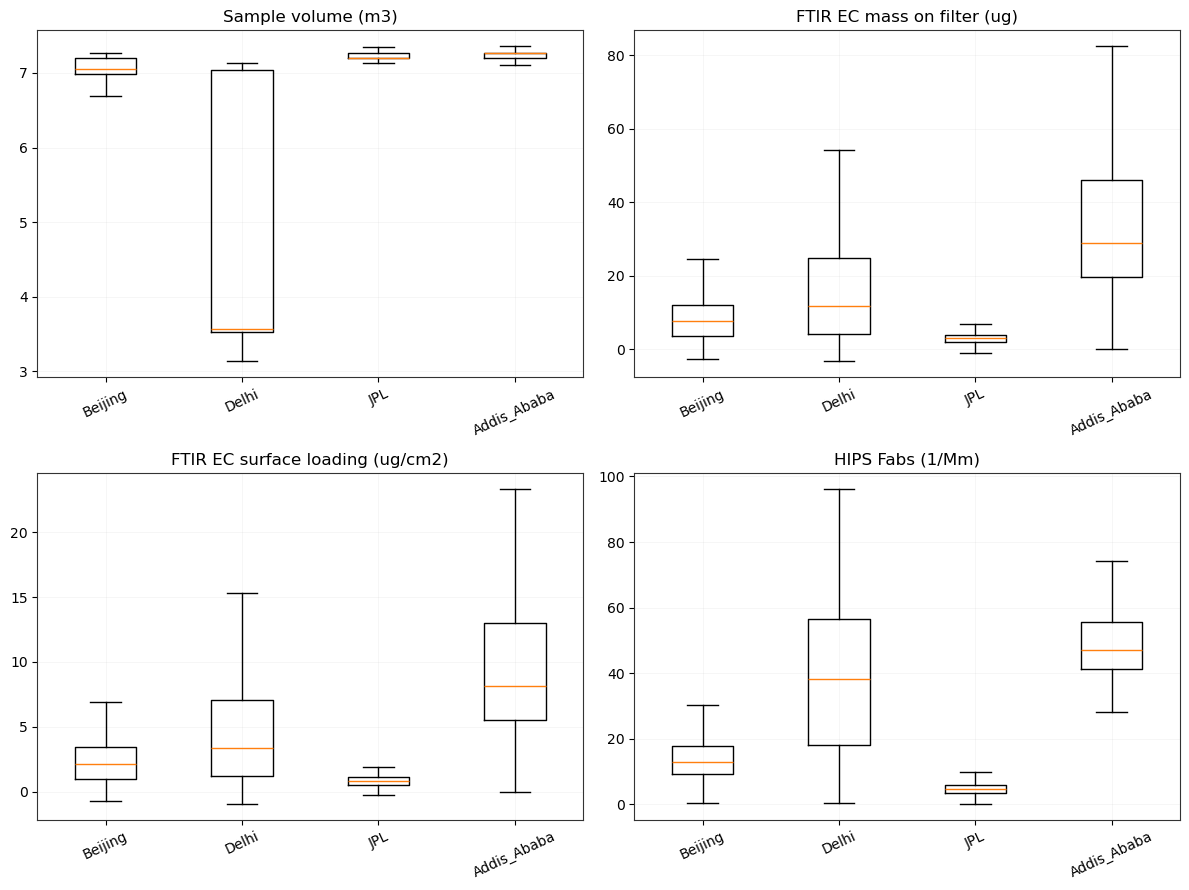

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_specs = [
    ("volume_m3", "Sample volume (m3)"),
    ("ec_mass_ug", "FTIR EC mass on filter (ug)"),
    ("ec_surface_loading_ug_cm2", "FTIR EC surface loading (ug/cm2)"),
    ("hips_fabs", "HIPS Fabs (1/Mm)"),
]
for ax, (col, label) in zip(axes.flat, plot_specs):
    data = [analysis.loc[analysis["site"] == s, col].dropna() for s in SITE_CODES]
    ax.boxplot(data, labels=list(SITE_CODES), showfliers=False)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, alpha=0.25)
plt.tight_layout()
fig_path = OUT_DIR / "spartan_loading_volume_envelope_boxplots.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(fig_path)
plt.show()


/Users/ahmadjalil/github/aethmodular/research/catch_up/output/02_loading_volume_operating_envelope/hips_fabs_vs_ec_surface_loading_four_sites.png


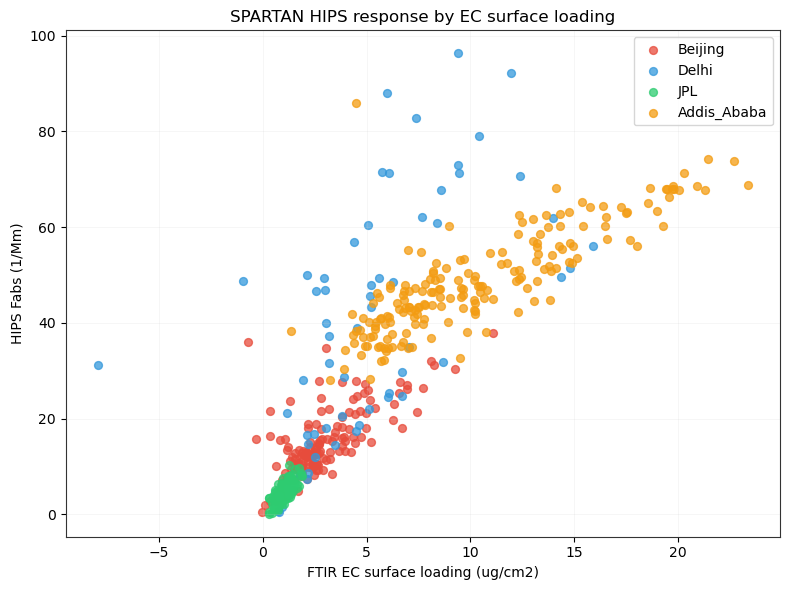

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
for site, color in SITE_COLORS.items():
    d = analysis[analysis["site"] == site]
    ax.scatter(d["ec_surface_loading_ug_cm2"], d["hips_fabs"], s=32, alpha=0.75, label=site, color=color)
ax.set_xlabel("FTIR EC surface loading (ug/cm2)")
ax.set_ylabel("HIPS Fabs (1/Mm)")
ax.set_title("SPARTAN HIPS response by EC surface loading")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
fig_path = OUT_DIR / "hips_fabs_vs_ec_surface_loading_four_sites.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(fig_path)
plt.show()
